In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

In [2]:
engine = create_engine(r"sqlite:///C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\data\db\bluestock_mf.db")

In [3]:
nav = pd.read_sql("SELECT * FROM fact_nav", engine)
fund = pd.read_sql("SELECT * FROM dim_fund", engine)
transactions = pd.read_sql("SELECT * FROM fact_transactions", engine)
performance = pd.read_sql("SELECT * FROM fact_performance", engine)
portfolio = pd.read_sql("SELECT * FROM fact_portfolio", engine)

In [4]:
nav['date'] = pd.to_datetime(nav['date'])
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])
print("All tables loaded")
print(f"NAV: {nav.shape}")
print(f"Transactions: {transactions.shape}")

All tables loaded
NAV: (46000, 3)
Transactions: (32778, 13)


In [5]:
nav_pivot = nav.pivot(index='date', columns='amfi_code', values='nav')
daily_returns = nav_pivot.pct_change().dropna()

var_results = []

for code in daily_returns.columns:
    fund_returns = daily_returns[code].dropna()
    
    var_95 = np.percentile(fund_returns, 5)
    
    cvar_95 = fund_returns[fund_returns <= var_95].mean()
    
    name = fund[fund['amfi_code'] == code]['scheme_name'].values
    name = name[0] if len(name) > 0 else code
    
    var_results.append({
        'amfi_code': code,
        'scheme_name': name,
        'var_95_pct': round(var_95 * 100, 4),
        'cvar_95_pct': round(cvar_95 * 100, 4)
    })

var_df = pd.DataFrame(var_results)
var_df.to_csv(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\data\processed\var_cvar_report.csv", index=False)

print("VaR and CVaR computed")
print(var_df.sort_values('var_95_pct').head(10))

VaR and CVaR computed
    amfi_code                                        scheme_name  var_95_pct  \
22     119599          SBI Small Cap Fund - Direct Plan - Growth     -2.6859   
17     119095             Axis Small Cap Fund - Regular - Growth     -2.6188   
4      101207             ABSL Small Cap Fund - Regular - Growth     -2.6021   
11     118634     Nippon India Small Cap Fund - Regular - Growth     -2.5438   
21     119598         SBI Small Cap Fund - Regular Plan - Growth     -2.4507   
39     149324              DSP Small Cap Fund - Regular - Growth     -2.3483   
7      102886                UTI Mid Cap Fund - Regular - Growth     -1.9220   
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...     -1.9034   
25     120505           ICICI Pru Midcap Fund - Regular - Growth     -1.8892   
16     119094                Axis Midcap Fund - Regular - Growth     -1.8480   

    cvar_95_pct  
22      -3.2384  
17      -3.1667  
4       -3.2459  
11      -3.2304  
21     

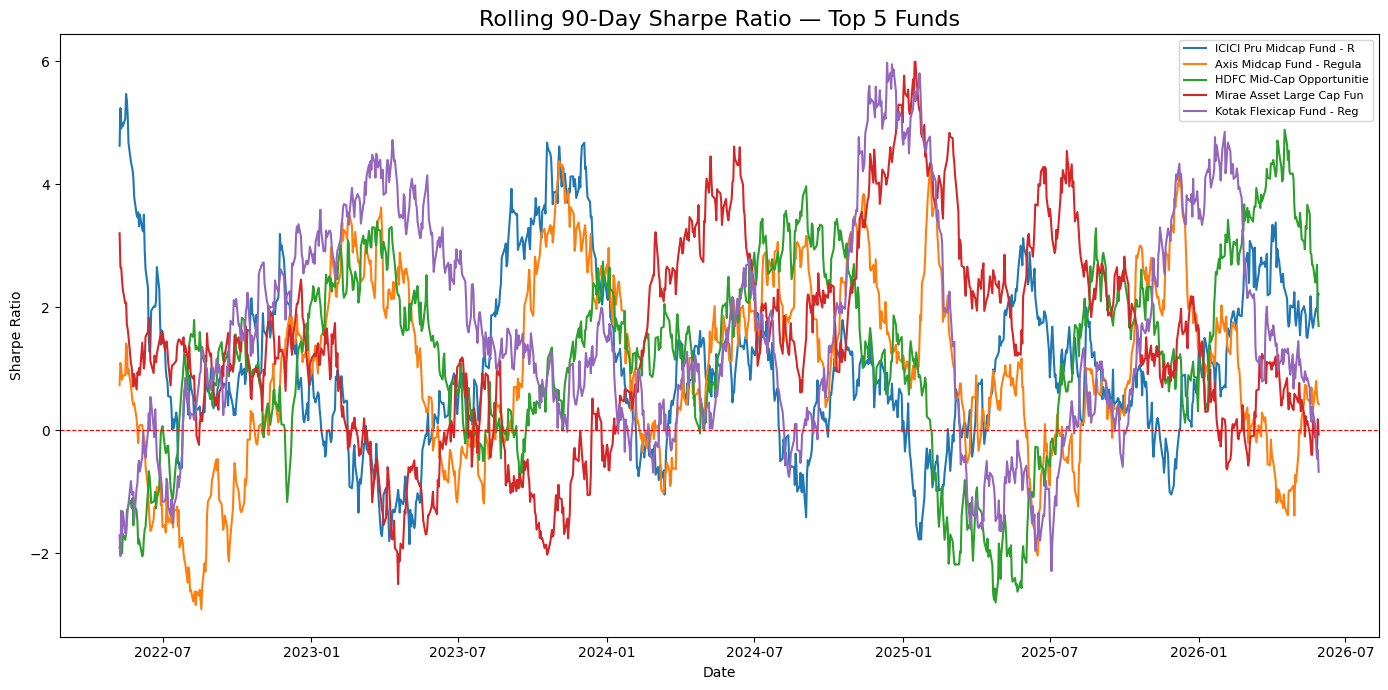

Rolling Sharpe chart saved


In [6]:
Rf = 0.065 / 252

top5_codes = [120505, 119094, 100033, 148567, 120843]

plt.figure(figsize=(14, 7))

for code in top5_codes:
    fund_returns = daily_returns[code].dropna()
    
    rolling_sharpe = (
        (fund_returns.rolling(90).mean() - Rf) /
        fund_returns.rolling(90).std()
    ) * np.sqrt(252)
    
    name = fund[fund['amfi_code'] == code]['scheme_name'].values[0][:25]
    plt.plot(rolling_sharpe.index, rolling_sharpe, linewidth=1.5, label=name)

plt.title('Rolling 90-Day Sharpe Ratio — Top 5 Funds', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend(fontsize=8)
plt.axhline(y=0, color='red', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\reports\rolling_sharpe_chart.png", dpi=150)
plt.show()
print("Rolling Sharpe chart saved")

In [7]:
transactions['year'] = transactions['transaction_date'].dt.year

first_tx = transactions.groupby('investor_id')['transaction_date'].min().reset_index()
first_tx['cohort_year'] = first_tx['transaction_date'].dt.year

transactions = transactions.merge(first_tx[['investor_id', 'cohort_year']], on='investor_id')

cohort = transactions.groupby('cohort_year').agg(
    avg_sip_amount=('amount_inr', 'mean'),
    total_invested=('amount_inr', 'sum'),
    num_investors=('investor_id', 'nunique'),
    num_transactions=('investor_id', 'count')
).reset_index()

cohort['avg_sip_amount'] = cohort['avg_sip_amount'].round(2)
cohort.to_csv(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\data\processed\cohort_analysis.csv", index=False)

print("Cohort Analysis computed")
print(cohort)

Cohort Analysis computed
   cohort_year  avg_sip_amount  total_invested  num_investors  \
0         2024       107422.54      3491125187           4803   
1         2025       109158.58        30455243            197   

   num_transactions  
0             32499  
1               279  


In [8]:
sip_tx = transactions[transactions['transaction_type'] == 'SIP'].copy()

sip_tx = sip_tx.sort_values(['investor_id', 'transaction_date'])

sip_tx['prev_date'] = sip_tx.groupby('investor_id')['transaction_date'].shift(1)
sip_tx['gap_days'] = (sip_tx['transaction_date'] - sip_tx['prev_date']).dt.days

sip_count = sip_tx.groupby('investor_id')['transaction_date'].count()
active_investors = sip_count[sip_count >= 6].index

sip_active = sip_tx[sip_tx['investor_id'].isin(active_investors)]

avg_gap = sip_active.groupby('investor_id')['gap_days'].mean().reset_index()
avg_gap.columns = ['investor_id', 'avg_gap_days']

avg_gap['status'] = avg_gap['avg_gap_days'].apply(
    lambda x: 'At-Risk' if x > 35 else 'Regular'
)

avg_gap.to_csv(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\data\processed\sip_continuity.csv", index=False)

print("SIP Continuity Analysis computed")
print(f"Total active investors: {len(avg_gap)}")
print(f"At-Risk investors: {len(avg_gap[avg_gap['status'] == 'At-Risk'])}")
print(f"Regular investors: {len(avg_gap[avg_gap['status'] == 'Regular'])}")

SIP Continuity Analysis computed
Total active investors: 1362
At-Risk investors: 1332
Regular investors: 30


In [9]:
def recommend_funds(risk_appetite):
    """
    Input: risk_appetite — Low / Moderate / High
    Output: Top 3 funds by Sharpe ratio within matching risk grade
    """
    risk_map = {
        'Low': ['Low'],
        'Moderate': ['Moderate', 'Moderately High'],
        'High': ['High', 'Very High']
    }
    
    grades = risk_map.get(risk_appetite, [])
    
    filtered = performance[performance['risk_grade'].isin(grades)]
    
    top3 = filtered.nlargest(3, 'sharpe_ratio')[
        ['scheme_name', 'fund_house', 'sharpe_ratio', 
         'return_3yr_pct', 'risk_grade']
    ]
    
    print(f"\nTop 3 Recommended Funds for {risk_appetite} Risk Appetite:")
    print(top3.to_string(index=False))
    return top3

recommend_funds('Low')
recommend_funds('Moderate')
recommend_funds('High')


Top 3 Recommended Funds for Low Risk Appetite:
                             scheme_name               fund_house  sharpe_ratio  return_3yr_pct risk_grade
ICICI Pru Liquid Fund - Regular - Growth      ICICI Prudential MF          7.68            7.68        Low
    Kotak Liquid Fund - Regular - Growth        Kotak Mahindra MF          6.18            6.18        Low
     ABSL Liquid Fund - Regular - Growth Aditya Birla Sun Life MF          5.14            5.14        Low

Top 3 Recommended Funds for Moderate Risk Appetite:
                                  scheme_name          fund_house  sharpe_ratio  return_3yr_pct risk_grade
    HDFC Top 100 Fund - Regular Plan - Growth    HDFC Mutual Fund          1.06           14.84   Moderate
Mirae Asset Large Cap Fund - Regular - Growth      Mirae Asset MF          1.06           14.81   Moderate
    ICICI Pru Bluechip Fund - Direct - Growth ICICI Prudential MF          1.03           14.41   Moderate

Top 3 Recommended Funds for High Risk Appe

,scheme_name,fund_house,sharpe_ratio,return_3yr_pct,risk_grade
21,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,0.96,18.23,High
12,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,0.95,18.08,High
2,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,0.94,23.39,Very High


In [10]:
recommender_code = '''
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine(r"sqlite:///C:\\Users\\ASUS\\Desktop\\Bluestock_MF_Capstone_Project\\data\\db\\bluestock_mf.db")
performance = pd.read_sql("SELECT * FROM fact_performance", engine)

def recommend_funds(risk_appetite):
    risk_map = {
        "Low": ["Low"],
        "Moderate": ["Moderate", "Moderately High"],
        "High": ["High", "Very High"]
    }
    grades = risk_map.get(risk_appetite, [])
    filtered = performance[performance["risk_grade"].isin(grades)]
    top3 = filtered.nlargest(3, "sharpe_ratio")[
        ["scheme_name", "fund_house", "sharpe_ratio", "return_3yr_pct", "risk_grade"]
    ]
    print(f"\\nTop 3 Recommended Funds for {risk_appetite} Risk Appetite:")
    print(top3.to_string(index=False))
    return top3

recommend_funds("Low")
recommend_funds("Moderate")
recommend_funds("High")
'''

with open(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\scripts\recommender.py", "w") as f:
    f.write(recommender_code)

print("recommender.py saved")

recommender.py saved


In [11]:
hhi_results = []

for code in portfolio['amfi_code'].unique():
    fund_portfolio = portfolio[portfolio['amfi_code'] == code]
    
    name = fund[fund['amfi_code'] == code]['scheme_name'].values
    name = name[0] if len(name) > 0 else code
    
    sector_weights = fund_portfolio.groupby('sector')['weight_pct'].sum()
    
    hhi = (sector_weights ** 2).sum()
    
    hhi_results.append({
        'amfi_code': code,
        'scheme_name': name,
        'hhi': round(hhi, 2),
        'concentration': 'High' if hhi > 2500 else 'Moderate' if hhi > 1500 else 'Low'
    })

hhi_df = pd.DataFrame(hhi_results)
hhi_df.to_csv(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\data\processed\sector_hhi.csv", index=False)

print("HHI computed")
print(hhi_df.sort_values('hhi', ascending=False).head(10))

HHI computed
    amfi_code                                        scheme_name      hhi  \
19     119092              Axis Bluechip Fund - Regular - Growth  2967.69   
30     148569      Mirae Asset Tax Saver Fund - Regular - Growth  2549.92   
7      125498  HDFC Mid-Cap Opportunities Fund - Direct - Growth  2531.55   
27     102887              UTI Flexi Cap Fund - Regular - Growth  2513.83   
32     149323                 DSP Midcap Fund - Regular - Growth  2410.77   
10     120505           ICICI Pru Midcap Fund - Regular - Growth  2386.95   
15     118635                     Nippon India ETF Nifty 50 BeES  2374.97   
3      119599          SBI Small Cap Fund - Direct Plan - Growth  2323.61   
11     120506  ICICI Pru Value Discovery Fund - Regular - Growth  2314.64   
6      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  2276.47   

   concentration  
19          High  
30          High  
7           High  
27          High  
32      Moderate  
10      Moderate  
15    

In [ ]:
## Advanced Analytics — Key Insights

1. Highest Risk (VaR) — SBI Small Cap Direct has highest daily VaR of -2.69% 
   meaning on a bad day investors can lose up to 2.69% of their investment

2. Rolling Sharpe — All top 5 funds show positive Sharpe ratio for majority 
   of 2022-2026 period with peak performance in mid 2024-2025

3. Cohort Analysis — 2025 cohort investors have higher avg SIP (Rs.1.09L) 
   vs 2024 cohort (Rs.1.07L) showing growing investor confidence

4. SIP Continuity — 97.8% of active investors are at-risk with transaction 
   gaps exceeding 35 days — major retention challenge for AMCs

5. Sector Concentration — Axis Bluechip has highest HHI of 2967 indicating 
   concentrated sector bets while most funds are moderately diversified